In [1]:
"""Use Perona-Malik regularistion to deblur image"""

'Use Perona-Malik regularistion to deblur image'

In [2]:
from functools import partial

from matplotlib.colors import CenteredNorm
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import scipy.sparse as sp

from deblurring.blurring import blur_and_noise
from solvers.least_square import LSQRSolver
from common.operators import derivative_operator, dx_operator, dy_operator, identity_operator, perona_malik_operator
from evaluation.tuning import StandardTuner, IterativeTuner

Estimated noise variance 2.6044475419839987e-05 vs. actual 2.5899715383858184e-05


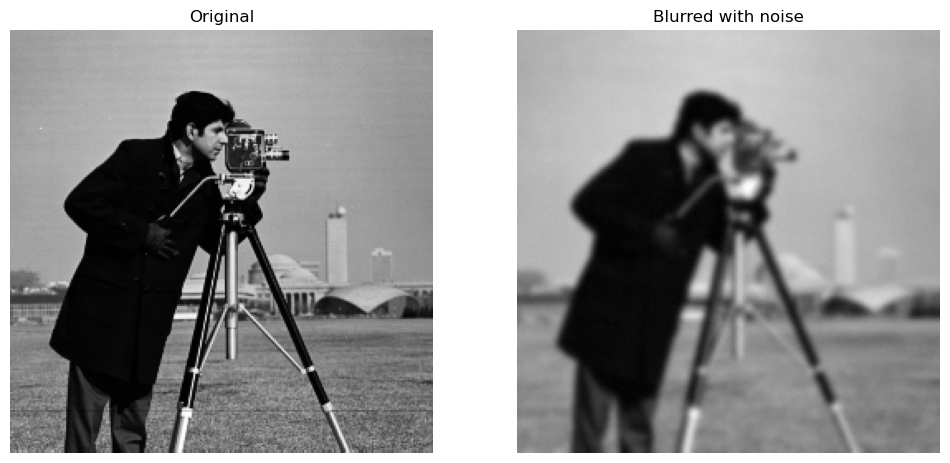

In [3]:
"""Read image and blur with added noise"""

f = plt.imread("../../data/Cameraman256.png")
f = (f - f.min()) / (f.max() - f.min())

theta = 0.02 * np.std(f)  # 2% noise
sigma = 2.0
kernel = partial(gaussian_filter, sigma=sigma)
g = blur_and_noise(f, kernel, theta)
noise_variance = np.var(blur_and_noise(np.zeros_like(g), kernel, theta))
print(f"Estimated noise variance {noise_variance} vs. actual {np.square(theta)}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Original")
plt.subplot(1, 2, 2)
plt.imshow(g, cmap="gray")
plt.axis("off")
plt.title("Blurred with noise")
plt.show()

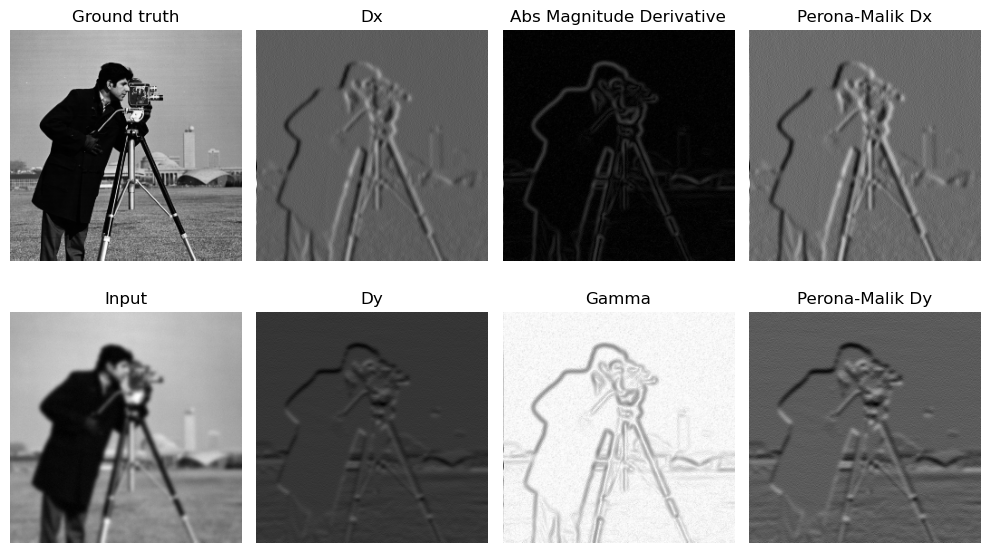

In [4]:
"""Visualise Perona-Malik regularisation"""

Dx = dx_operator(g, conv_mode="periodic")
Dy = dy_operator(g, conv_mode="periodic")
flat_dims = np.prod(g.shape)
dx_g = Dx @ g.flatten()
dy_g = Dy @ g.flatten()
abs_derivative = np.sqrt(np.square(dx_g) + np.square(dy_g))
threshold = 0.5 * np.max(abs_derivative)
gamma = np.exp(-abs_derivative / threshold)
gamma_diag_hat = np.sqrt(sp.diags(gamma.ravel()))
pm = sp.vstack([gamma_diag_hat @ Dx, gamma_diag_hat @ Dy])
pm_g = pm @ g.flatten()

fig, axs = plt.subplots(2, 4, figsize=(10, 6))

axs[0, 0].imshow(f, cmap="gray")
axs[0, 0].set_title("Ground truth")
axs[0, 0].axis("off")
axs[0, 1].imshow(dx_g.reshape(g.shape), cmap="gray")
axs[0, 1].set_title("Dx")
axs[0, 1].axis("off")
axs[0, 2].imshow(abs_derivative.reshape(g.shape), cmap="gray")
axs[0, 2].set_title("Abs Magnitude Derivative")
axs[0, 2].axis("off")
axs[0, 3].imshow(pm_g[0:flat_dims].reshape(g.shape), cmap="gray")
axs[0, 3].set_title("Perona-Malik Dx")
axs[0, 3].axis("off")
axs[1, 0].imshow(g, cmap="gray")
axs[1, 0].set_title("Input")
axs[1, 0].axis("off")
axs[1, 1].imshow(dy_g.reshape(g.shape), cmap='gray')
axs[1, 1].set_title("Dy")
axs[1, 1].axis("off")
axs[1, 2].imshow(gamma.reshape(g.shape), cmap="gray")
axs[1, 2].set_title("Gamma")
axs[1, 2].axis("off")
axs[1, 3].imshow(pm_g[flat_dims:].reshape(g.shape), cmap="gray")
axs[1, 3].set_title("Perona-Malik Dy")
axs[1, 3].axis("off")

plt.tight_layout()
plt.show()

In [5]:
"""Set up parameters"""

alphas = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1e0, 5e0]

[INFO] 2025-02-25 20:36:41 | Alpha 0.0001: discrepancy -5.361551711488423e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:42 | Alpha 0.0005: discrepancy -4.5028019137676e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:43 | Alpha 0.001: discrepancy -3.732873471683157e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:44 | Alpha 0.005: discrepancy 5.715965834527402e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:44 | Alpha 0.01: discrepancy 2.9269774866553436e-05 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:44 | Alpha 0.05: discrepancy 0.0006487628667321251 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:44 | Alpha 0.1: discrepancy 0.002302187915575628 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:45 | Alpha 0.5: discrepancy 0.029803467665394507 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:45 | Alpha 1.0: discrepancy 0.066439

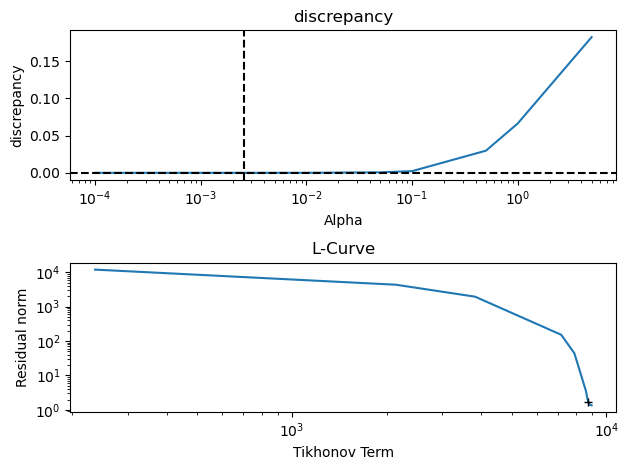

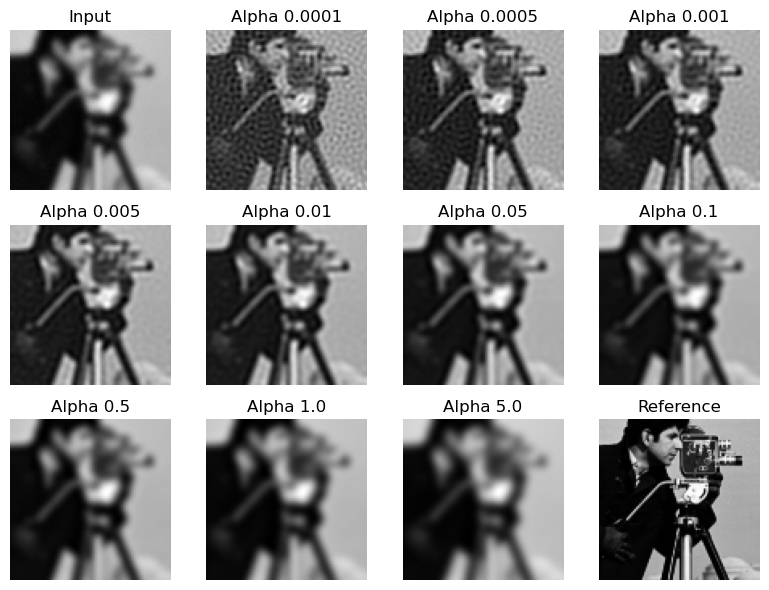

In [6]:
"""Optimise for TK0"""

lsqr_tk0 = StandardTuner(
    solver=LSQRSolver,
    g=g,
    A=kernel,
    noise_variance=noise_variance,
    f=f,
)
lsqr_tk0.parameter_sweep(
    alphas=alphas, L_func=identity_operator,
    x0=g,
    save_imgs=True,
)
print(f"Optimal alpha: {lsqr_tk0.optimal_alpha}")
print(f"DP: {lsqr_tk0.optimal_metrics['discrepancy']}, MSE: {lsqr_tk0.optimal_metrics['MSE']}")
lsqr_tk0.display_metrics()
lsqr_tk0.display_sample(slice(50, 150), slice(80, 180))

[INFO] 2025-02-25 20:36:49 | Alpha 0.0001: discrepancy -5.116255971375728e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:51 | Alpha 0.0005: discrepancy -4.204201926386791e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:53 | Alpha 0.001: discrepancy -3.641517984791989e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:54 | Alpha 0.005: discrepancy -9.636356365399654e-07 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:55 | Alpha 0.01: discrepancy 1.7880989379340246e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:56 | Alpha 0.05: discrepancy 2.1729392381740484e-05 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:57 | Alpha 0.1: discrepancy 4.5421134545749926e-05 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:58 | Alpha 0.5: discrepancy 0.00021802505463394423 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:36:59 | Alpha 1.0: discrepancy 

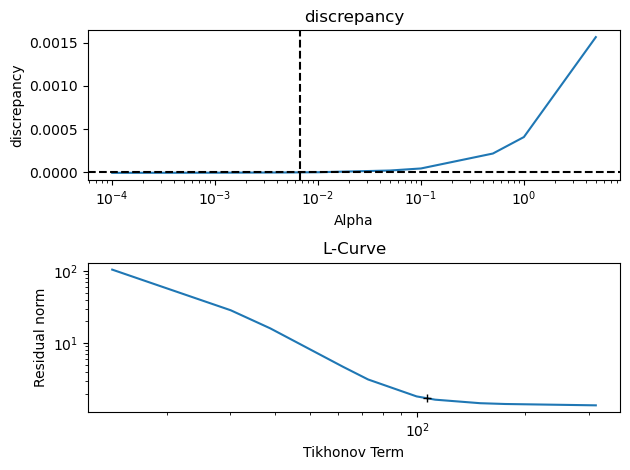

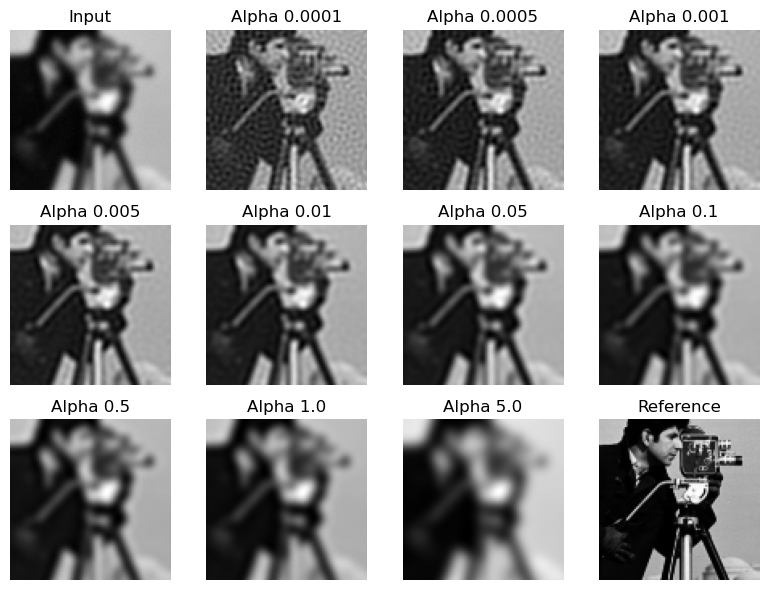

In [7]:
"""Optimise for TK1"""

lsqr_tk1 = StandardTuner(
    solver=LSQRSolver,
    g=g,
    A=kernel,
    noise_variance=noise_variance,
    f=f,
)
lsqr_tk1.parameter_sweep(
    alphas=alphas,
    L_func=derivative_operator,
    x0=g,
    save_imgs=True,
)
print(f"Optimal alpha: {lsqr_tk1.optimal_alpha}")
print(f"DP: {lsqr_tk1.optimal_metrics['discrepancy']}, MSE: {lsqr_tk1.optimal_metrics['MSE']}")
lsqr_tk1.display_metrics()
lsqr_tk1.display_sample(slice(50, 150), slice(80, 180))

[INFO] 2025-02-25 20:37:05 | Alpha 0.0001: discrepancy -5.151047604078257e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:07 | Alpha 0.0005: discrepancy -4.457774210395956e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:08 | Alpha 0.001: discrepancy -3.97129220502494e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:10 | Alpha 0.005: discrepancy -2.249527144746116e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:11 | Alpha 0.01: discrepancy -5.44234362408478e-07 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:12 | Alpha 0.05: discrepancy 1.069100203662465e-05 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:13 | Alpha 0.1: discrepancy 2.5981031568830938e-05 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:14 | Alpha 0.5: discrepancy 0.00013677756964085373 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:15 | Alpha 1.0: discrepancy 0.0

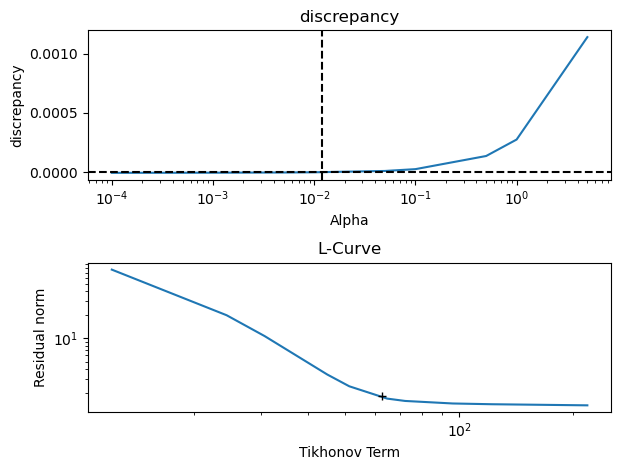

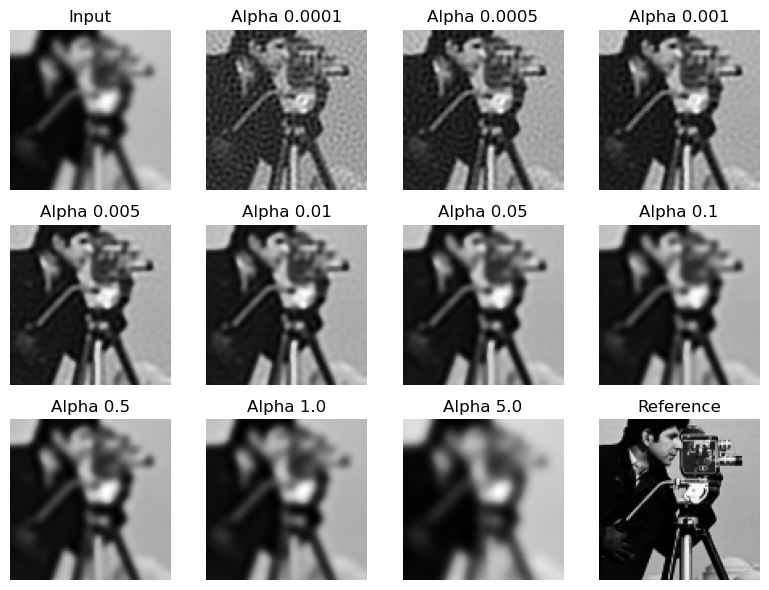

In [8]:
"""Optimise and generate example images Perona-Malik"""

lsqr_pm = StandardTuner(
    solver=LSQRSolver,
    g=g,
    A=kernel,
    noise_variance=noise_variance,
    f=f,
)
lsqr_pm.parameter_sweep(
    alphas=alphas,
    L_func=perona_malik_operator,
    x0=g,
    save_imgs=True,
)
print(f"Optimal alpha: {lsqr_pm.optimal_alpha}")
print(f"DP: {lsqr_pm.optimal_metrics['discrepancy']}, MSE: {lsqr_pm.optimal_metrics['MSE']}")
lsqr_pm.display_metrics()
lsqr_pm.display_sample(slice(50, 150), slice(80, 180))

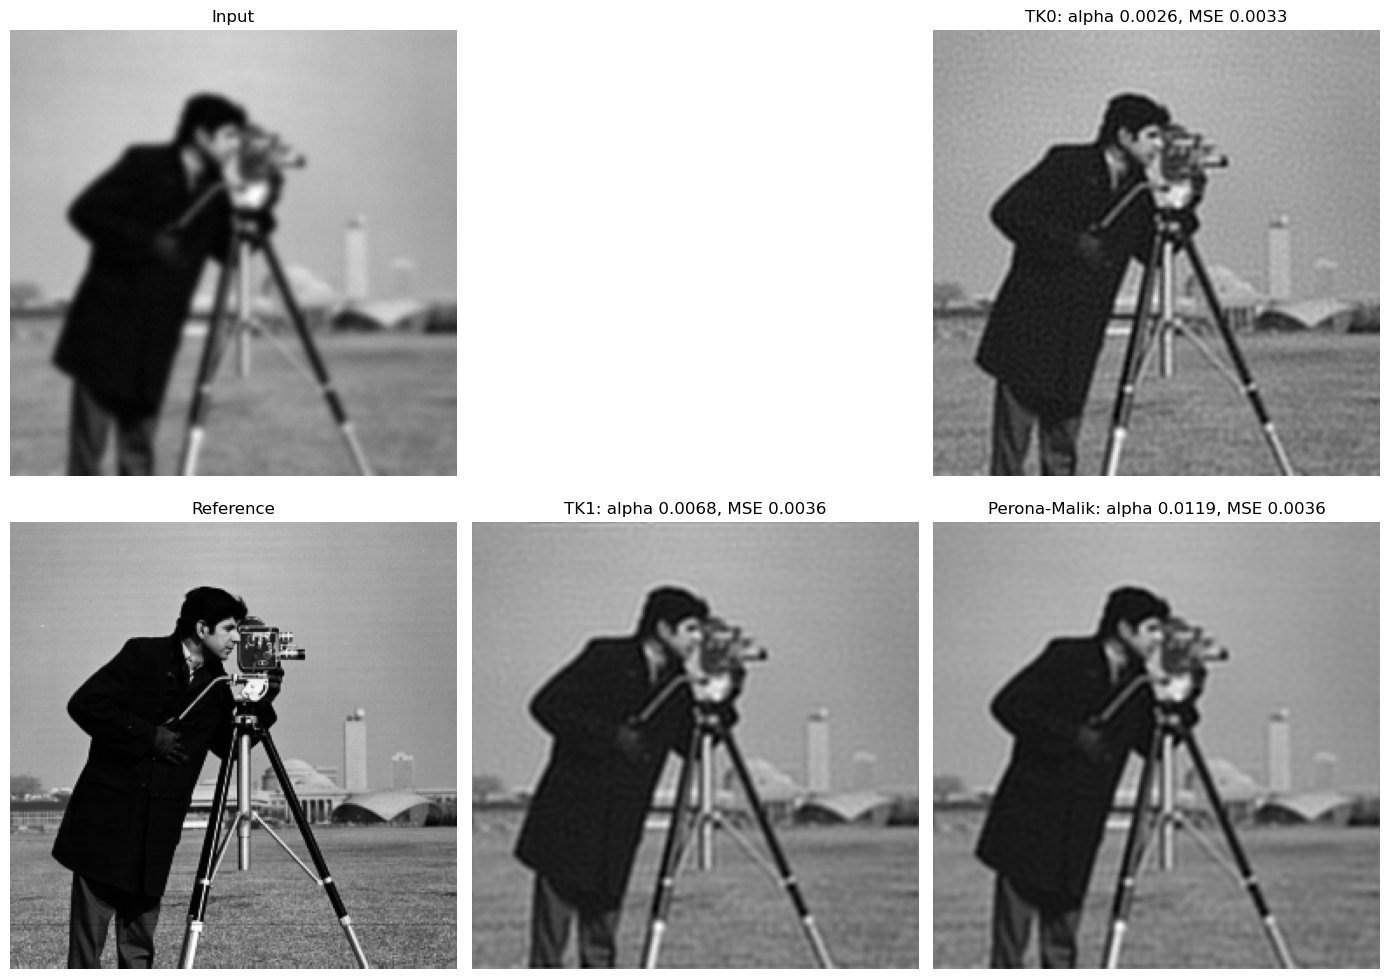

In [9]:
"""Compare regularisation techniques"""

_, axs = plt.subplots(2, 3, figsize=(14, 10))

axs[0, 0].imshow(g, cmap="gray")
axs[0, 0].set_title("Input")
axs[0, 0].axis("off")
axs[0, 1].axis("off")
axs[1, 0].imshow(f, cmap="gray")
axs[1, 0].set_title("Reference")
axs[1, 0].axis("off")
axs[0, 2].imshow(lsqr_tk0._optimal_f_hat, cmap="gray")
axs[0, 2].set_title(f"TK0: alpha {lsqr_tk0.optimal_alpha:.4f}, MSE {lsqr_tk0.optimal_metrics['MSE']:.4f}")
axs[0, 2].axis("off")
axs[1, 1].imshow(lsqr_tk1._optimal_f_hat, cmap="gray")
axs[1, 1].set_title(f"TK1: alpha {lsqr_tk1.optimal_alpha:.4f}, MSE {lsqr_tk1.optimal_metrics['MSE']:.4f}")
axs[1, 1].axis("off")
axs[1, 2].imshow(lsqr_pm._optimal_f_hat, cmap="gray")
axs[1, 2].set_title(f"Perona-Malik: alpha {lsqr_pm.optimal_alpha:.4f}, MSE {lsqr_pm.optimal_metrics['MSE']:.4f}")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

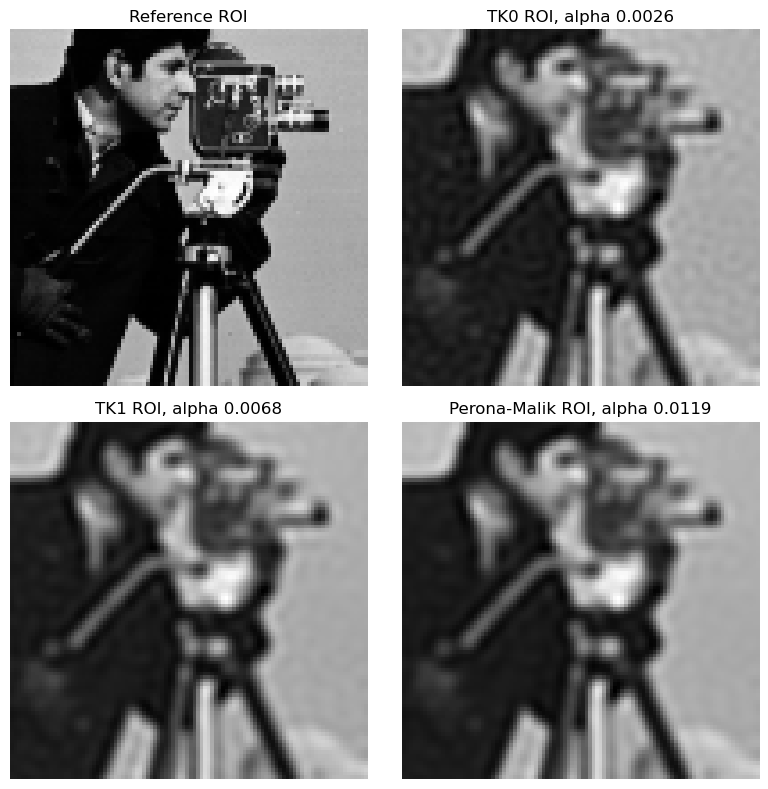

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

axs[0, 0].imshow(f[50:150, 80:180], cmap="gray")
axs[0, 0].set_title("Reference ROI")
axs[0, 0].axis("off")
axs[0, 1].imshow(lsqr_tk0.optimal_f_hat[50:150, 80:180], cmap="gray")
axs[0, 1].set_title(f"TK0 ROI, alpha {lsqr_tk0.optimal_alpha:.4f}")
axs[0, 1].axis("off")
axs[1, 0].imshow(lsqr_tk1.optimal_f_hat[50:150, 80:180], cmap="gray")
axs[1, 0].set_title(f"TK1 ROI, alpha {lsqr_tk1.optimal_alpha:.4f}")
axs[1, 0].axis("off")
axs[1, 1].imshow(lsqr_pm.optimal_f_hat[50:150, 80:180], cmap="gray")
axs[1, 1].set_title(f"Perona-Malik ROI, alpha {lsqr_pm.optimal_alpha:.4f}")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

[INFO] 2025-02-25 20:37:35 | Alpha 0.0001: discrepancy -5.310337470289047e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:37:56 | Alpha 0.0005: discrepancy -4.385962208899088e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:38:19 | Alpha 0.001: discrepancy -3.899515449240139e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:38:48 | Alpha 0.005: discrepancy -1.952568562162836e-06 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:39:23 | Alpha 0.01: discrepancy -1.5894464590536676e-07 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:39:49 | Alpha 0.05: discrepancy 1.2440848824088792e-05 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:40:08 | Alpha 0.1: discrepancy 2.8194882611360918e-05 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:40:25 | Alpha 0.5: discrepancy 0.00014898461831937761 | evaluation.eval_metrics-log_metrics:209
[INFO] 2025-02-25 20:40:42 | Alpha 1.0: discrepancy

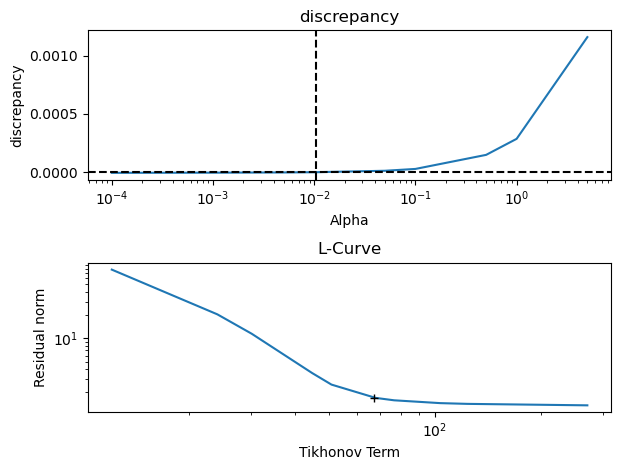

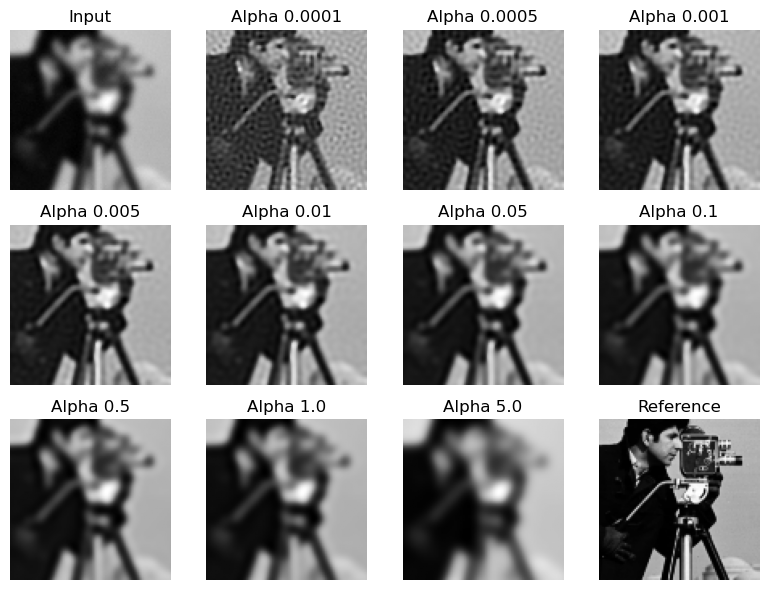

In [11]:
"""Generate example images using iterative Perona-Malik"""

lsqr_pm_iter = IterativeTuner(
    solver=LSQRSolver,
    g=g,
    A=kernel,
    noise_variance=noise_variance,
    f=f,
)
lsqr_pm_iter.parameter_sweep(
    alphas=alphas,
    L_func=perona_malik_operator,
    x0=g,
    save_imgs=True,
)
print(f"Optimal alpha: {lsqr_pm_iter.optimal_alpha}")
print(f"DP: {lsqr_pm_iter.optimal_metrics['discrepancy']}, MSE: {lsqr_pm_iter.optimal_metrics['MSE']}")
lsqr_pm_iter.display_metrics()
lsqr_pm_iter.display_sample(slice(50, 150), slice(80, 180))

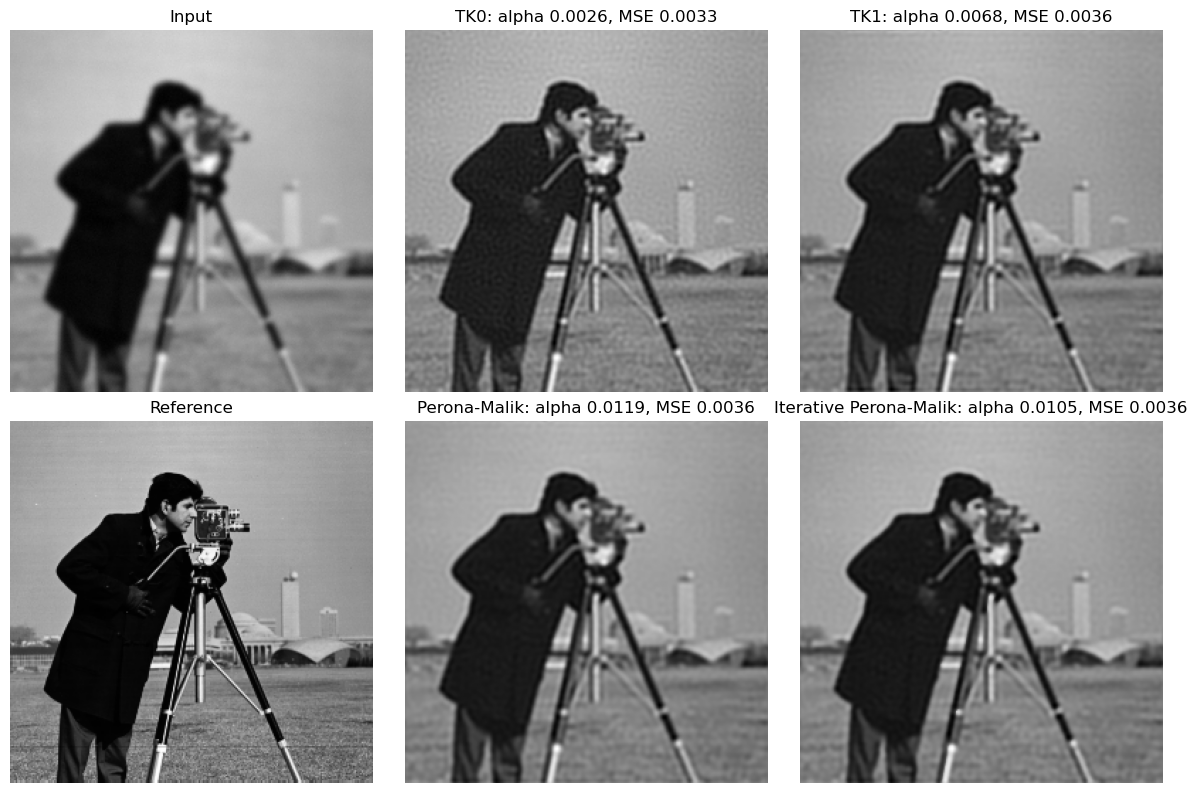

In [12]:
"""Compare regularisation techniques"""

fig, axs = plt.subplots(2, 3, figsize=(12, 8))

axs[0, 0].imshow(g, cmap="gray")
axs[0, 0].set_title("Input")
axs[0, 0].axis("off")
axs[1, 0].imshow(f, cmap="gray")
axs[1, 0].set_title("Reference")
axs[1, 0].axis("off")
axs[0, 1].imshow(lsqr_tk0.optimal_f_hat, cmap="gray")
axs[0, 1].set_title(f"TK0: alpha {lsqr_tk0.optimal_alpha:.4f}, MSE {lsqr_tk0.optimal_metrics['MSE']:.4f}")
axs[0, 1].axis("off")
axs[0, 2].imshow(lsqr_tk1.optimal_f_hat, cmap="gray")
axs[0, 2].set_title(f"TK1: alpha {lsqr_tk1.optimal_alpha:.4f}, MSE {lsqr_tk1.optimal_metrics['MSE']:.4f}")
axs[0, 2].axis("off")
axs[1, 1].imshow(lsqr_pm.optimal_f_hat, cmap="gray")
axs[1, 1].set_title(f"Perona-Malik: alpha {lsqr_pm.optimal_alpha:.4f}, MSE {lsqr_pm.optimal_metrics['MSE']:.4f}")
axs[1, 1].axis("off")
axs[1, 2].imshow(lsqr_pm_iter.optimal_f_hat, cmap="gray")
axs[1, 2].set_title(f"Iterative Perona-Malik: alpha {lsqr_pm_iter.optimal_alpha:.4f}, MSE {lsqr_pm.optimal_metrics['MSE']:.4f}")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

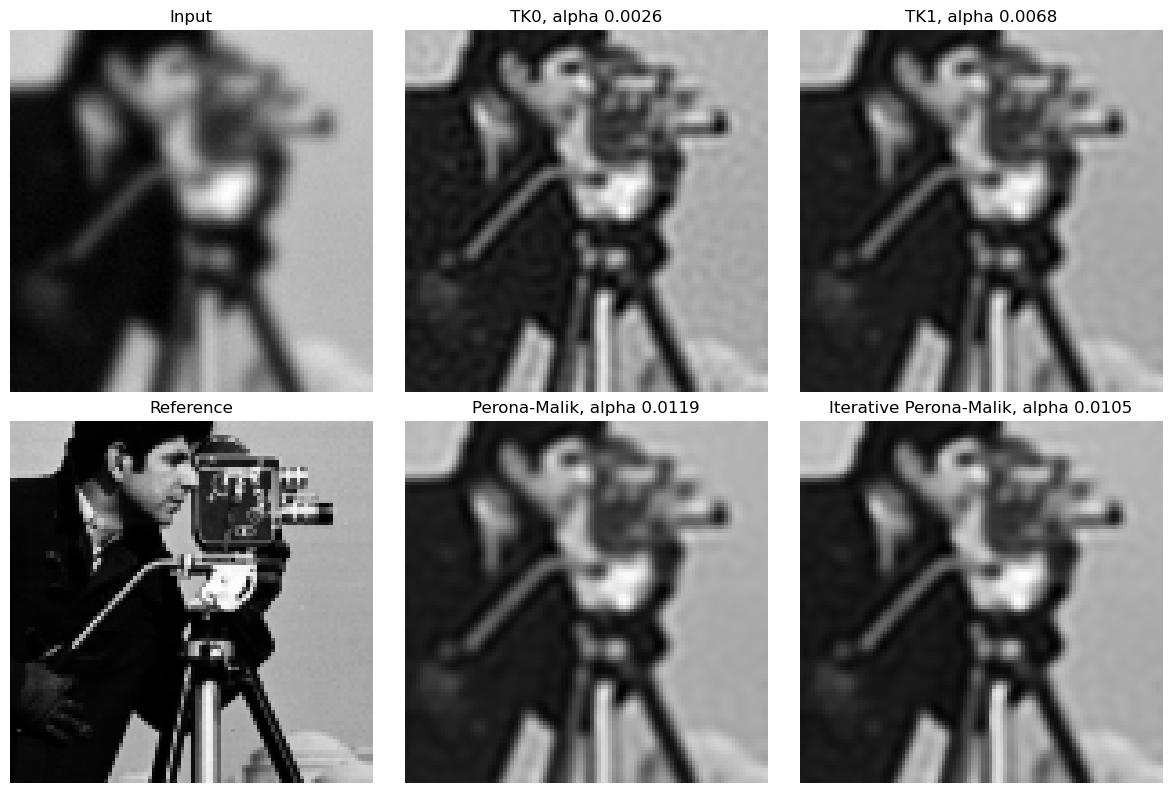

In [13]:
"""Compare regularisation techniques"""

fig, axs = plt.subplots(2, 3, figsize=(12, 8))

axs[0, 0].imshow(g[50:150, 80:180], cmap="gray")
axs[0, 0].set_title("Input")
axs[0, 0].axis("off")
axs[1, 0].imshow(f[50:150, 80:180], cmap="gray")
axs[1, 0].set_title("Reference")
axs[1, 0].axis("off")
axs[0, 1].imshow(lsqr_tk0.optimal_f_hat[50:150, 80:180], cmap="gray")
axs[0, 1].set_title(f"TK0, alpha {lsqr_tk0.optimal_alpha:.4f}")
axs[0, 1].axis("off")
axs[0, 2].imshow(lsqr_tk1.optimal_f_hat[50:150, 80:180], cmap="gray")
axs[0, 2].set_title(f"TK1, alpha {lsqr_tk1.optimal_alpha:.4f}")
axs[0, 2].axis("off")
axs[1, 1].imshow(lsqr_pm.optimal_f_hat[50:150, 80:180], cmap="gray")
axs[1, 1].set_title(f"Perona-Malik, alpha {lsqr_pm.optimal_alpha:.4f}")
axs[1, 1].axis("off")
axs[1, 2].imshow(lsqr_pm_iter.optimal_f_hat[50:150, 80:180], cmap="gray")
axs[1, 2].set_title(f"Iterative Perona-Malik, alpha {lsqr_pm_iter.optimal_alpha:.4f}")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [14]:
print(f"TK0: optimal alpha {lsqr_tk0.optimal_alpha:.4f}")
print(lsqr_tk0.optimal_metrics[["MSE", "pSNR", "SSIM"]])
print(f"TK1: optimal alpha {lsqr_tk1.optimal_alpha:.4f}")
print(lsqr_tk1.optimal_metrics[["MSE", "pSNR", "SSIM"]])
print(f"Perona-Malik: optimal alpha {lsqr_pm.optimal_alpha:.4f}")
print(lsqr_pm.optimal_metrics[["MSE", "pSNR", "SSIM"]])
print(f"Iterative Perona-Malik: optimal alpha {lsqr_pm_iter.optimal_alpha:.4f}")
print(lsqr_pm_iter.optimal_metrics[["MSE", "pSNR", "SSIM"]])

TK0: optimal alpha 0.0026
MSE     0.003275
pSNR    24.84824
SSIM    0.751063
Name: optimal, dtype: object
TK1: optimal alpha 0.0068
MSE      0.003609
pSNR    24.426624
SSIM     0.783166
Name: optimal, dtype: object
Perona-Malik: optimal alpha 0.0119
MSE      0.003617
pSNR    24.416344
SSIM      0.79128
Name: optimal, dtype: object
Iterative Perona-Malik: optimal alpha 0.0105
MSE      0.003421
pSNR    24.658571
SSIM     0.796724
Name: optimal, dtype: object


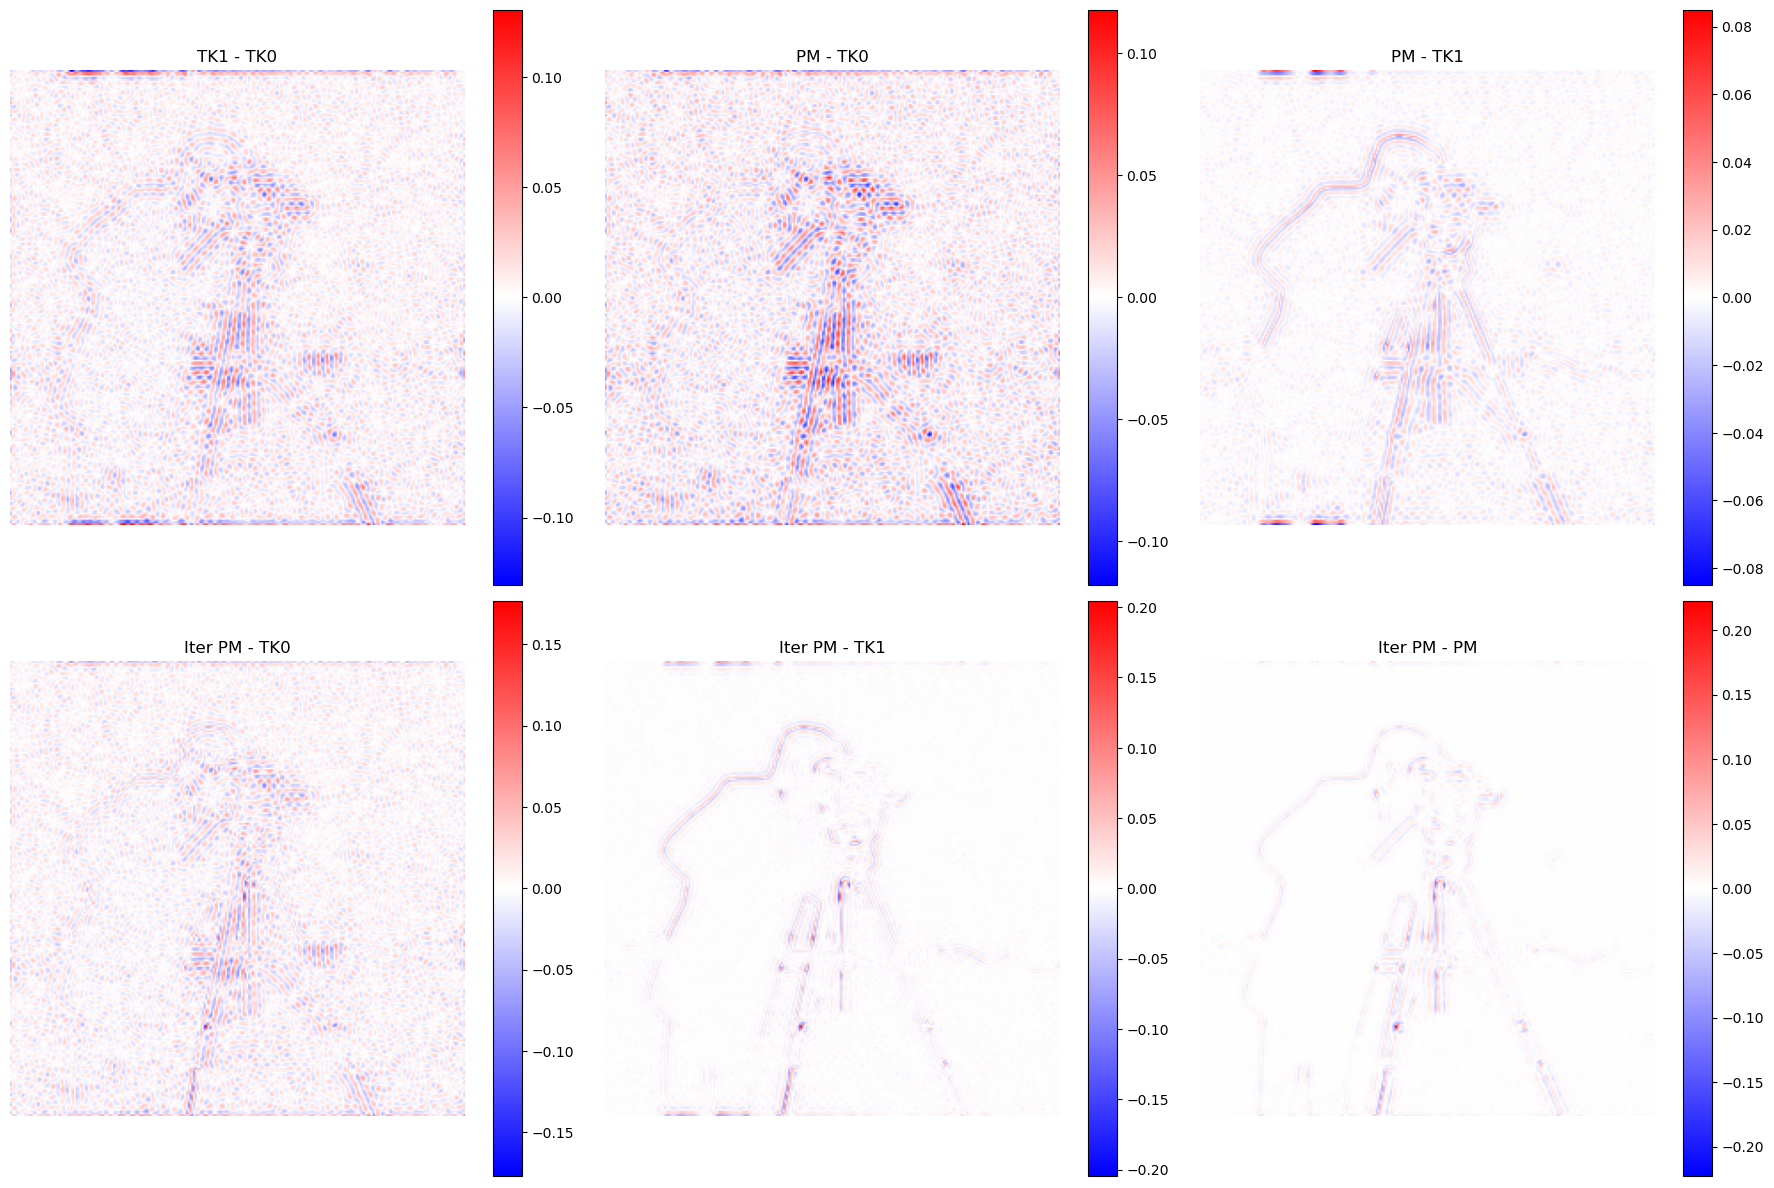

In [15]:
"""Compare errors between each technique"""

x_slice = slice(None, None)
y_slice = slice(None, None)
# x_slice = slice(50, 150)
# y_slice = slice(80, 180)

plt.figure(figsize=(18, 12))
plt.subplot(2, 3, 1)
plt.imshow(lsqr_tk1.optimal_f_hat[x_slice, y_slice] - lsqr_tk0.optimal_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("TK1 - TK0")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 2)
plt.imshow(lsqr_pm.optimal_f_hat[x_slice, y_slice] - lsqr_tk0.optimal_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("PM - TK0")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 3)
plt.imshow(lsqr_pm.optimal_f_hat[x_slice, y_slice] - lsqr_tk1.optimal_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("PM - TK1")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 4)
plt.imshow(lsqr_pm_iter.optimal_f_hat[x_slice, y_slice] - lsqr_tk0.optimal_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("Iter PM - TK0")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 5)
plt.imshow(lsqr_pm_iter.optimal_f_hat[x_slice, y_slice] - lsqr_tk1.optimal_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("Iter PM - TK1")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.subplot(2, 3, 6)
plt.imshow(lsqr_pm_iter.optimal_f_hat[x_slice, y_slice] - lsqr_pm.optimal_f_hat[x_slice, y_slice], norm=CenteredNorm(), cmap="bwr")
plt.title("Iter PM - PM")
plt.axis("off")
plt.colorbar(ax=plt.gca())
plt.tight_layout()
plt.show()
